# OrderFlow-Analysis-Pro — Repo Walkthrough on Historical Binance Data


## TL;DR

`Binance Parquet → Tick → CandleBuilder → Candle → Delta / CVD / Footprint → Volume Profile → Pattern Detectors → Profile Framing → SignalAggregator → Actions`

This notebook is a walkthrough of how `orderflow_system` works, using historical BTCUSDT Binance futures trades in place of the repo's live Bybit/MT5 feed. The question here is **how the repo works and how data flows through it** — not how profitable any strategy is. Every class used below is the repo's own, imported directly; nothing here is a new backtesting framework.


## 1. Repo Architecture

`orderflow_system` is a pipeline: raw trades become candles, candles feed several analytics engines, analytics feed pattern detectors, detector output plus multi-day profile context feeds a signal aggregator that runs a trade state machine. In live operation (`orderflow_system/main.py`), a feed (Bybit WS or MT5) supplies ticks; here, historical Binance parquet trades stand in for that feed.

| Component | Purpose | Input | Output |
|---|---|---|---|
| `Tick` (`data/models.py`) | One executed trade, repo's common currency | raw trade fields | `Tick` dataclass |
| `CandleBuilder` (`data/candle_builder.py`) | Aggregate ticks into time-based OHLCV bars with footprint | stream of `Tick` | `Candle` (on close) |
| `DeltaEngine` (`analytics/delta.py`) | Vertical/horizontal/cumulative delta | `Candle` | `DeltaResult` |
| `FootprintEngine` (`analytics/footprint.py`) | Per-price bid/ask volume, imbalance | `Candle` | `FootprintBar` |
| `VolumeProfileEngine` (`analytics/volume_profile.py`) | POC/VAH/VAL/LVN/shape from a volume histogram | candles for a session | `VolumeProfileResult` |
| `AbsorptionDetector`, `InitiativeDetector`, `ExhaustionDetector`, `DivergenceDetector` (`patterns/`) | Recognize specific effort-vs-result patterns | candle + delta + footprint (+ history) | `Signal` |
| `SweepDetector` (`patterns/sweep.py`) | Recognize low-effort book sweeps | L2 orderbook state | `Signal` |
| `ProfileFramingEngine` (`signals/profile_framing.py`) | Turn multi-day profiles into a directional bias + qualified levels | `VolumeProfileResult` history | `DailyBias` |
| `SignalAggregator` (`signals/aggregator.py`) | Score signals against bias/levels, drive a trade state machine | `Signal` + `DailyBias` | `AggregatedSignal` (action) |


## 2. Load Historical Binance Parquet

`orderflow_system` normally consumes a live tick stream (Bybit WebSocket or MT5). For historical study we substitute locally-stored Binance USDⓈ-M futures trade parquet files — same trade-level information, replayed in order instead of arriving live. Polars is used only to read, dedupe, and clean the raw files; every repo-facing step from here on uses the repo's own classes.


In [1]:
import datetime as dt
from pathlib import Path

import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

DATA_ROOT = Path(
    "/Users/bobet/Documents/Code-Repository/Trading/binance-data-feed/"
    "runtime/staging_local"
)
SYMBOL = "BTCUSDT"


def list_trade_days(root: Path, symbol: str) -> list[dt.date]:
    """UTC days that actually have parquet parts for `symbol`."""
    days = []
    for day_dir in sorted((root / "futures_trades").glob("date=*")):
        if next(day_dir.glob(f"hour=*/symbol={symbol}/*.parquet.ready"), None):
            days.append(dt.date.fromisoformat(day_dir.name.split("=", 1)[1]))
    return days


DAYS = list_trade_days(DATA_ROOT, SYMBOL)
print(f"{len(DAYS)} UTC days available: {DAYS[0]} .. {DAYS[-1]}")


32 UTC days available: 2026-06-26 .. 2026-07-30


## 3. Binance → Repo `Tick`

The repo's common language for a single executed trade is `Tick` (`orderflow_system/data/models.py`). Binance's raw trade schema maps onto it directly:

| Binance column | `Tick` field |
|---|---|
| `trade_time_ms` | `timestamp_ms` |
| `price` | `price` |
| `quantity` | `size` |
| `trade_id` | `trade_id` |

`is_buyer_maker` decides `side`: the field tells you whether the **buyer** was the passive (resting) side of the trade. `is_buyer_maker=True` → the buyer was passive → the trade was an aggressive **SELL**. `is_buyer_maker=False` → the seller was passive → the trade was an aggressive **BUY**. `Tick.side` is always the aggressor's side — that's what the repo's whole delta/footprint/detector logic keys on.


In [2]:
from orderflow_system.data.models import Tick, Side


def scan_day_trades(root: Path, symbol: str, day: dt.date) -> pl.LazyFrame:
    pattern = f"{root}/futures_trades/date={day.isoformat()}/hour=*/symbol={symbol}/*.parquet.ready"
    return pl.scan_parquet(pattern, hive_partitioning=False).select(
        "trade_time_ms", "price", "quantity", "is_buyer_maker", "trade_id", "source"
    )


def split_valid_trades(lf: pl.LazyFrame) -> tuple[pl.LazyFrame, pl.LazyFrame]:
    """Split a RAW (pre-dedup) trade LazyFrame into (valid, omitted) on price==0/quantity==0."""
    invalid = (pl.col("price") == 0) | (pl.col("quantity") == 0)
    return lf.filter(~invalid), lf.filter(invalid)


def dedupe_trades(lf: pl.LazyFrame) -> pl.LazyFrame:
    """REST backfill and the live WS stream can both report the same trade_id;
    prefer the REST copy and sort chronologically."""
    return (
        lf.with_columns(
            pl.col("source").replace_strict({"rest": 0, "ws": 1}, default=2).alias("_p")
        )
        .sort(["trade_id", "_p"])
        .unique(subset=["trade_id"], keep="first", maintain_order=True)
        .drop("_p", "source")
        .sort(["trade_time_ms", "trade_id"])
    )


def frame_to_ticks(df: pl.DataFrame):
    """Yield repo `Tick` objects from a deduped Binance trade frame."""
    cols = df.select("trade_time_ms", "price", "quantity", "is_buyer_maker", "trade_id")
    for ts_ms, price, qty, is_buyer_maker, trade_id in cols.iter_rows():
        yield Tick(
            timestamp_ms=int(ts_ms),
            price=float(price),
            size=float(qty),
            side=Side.SELL if is_buyer_maker else Side.BUY,
            trade_id=str(trade_id),
        )


_valid_lf, _ = split_valid_trades(scan_day_trades(DATA_ROOT, SYMBOL, DAYS[0]))
sample_frame = dedupe_trades(_valid_lf).head(5).collect()
sample_ticks = list(frame_to_ticks(sample_frame))
for t in sample_ticks:
    print(t)


Tick(timestamp_ms=1782479846384, price=59037.1, size=0.04, side=<Side.BUY: 'buy'>, trade_id='7835267607')
Tick(timestamp_ms=1782479846447, price=59037.0, size=0.076, side=<Side.SELL: 'sell'>, trade_id='7835267608')
Tick(timestamp_ms=1782479846463, price=59037.1, size=0.014, side=<Side.BUY: 'buy'>, trade_id='7835267609')
Tick(timestamp_ms=1782479846469, price=59037.0, size=0.218, side=<Side.SELL: 'sell'>, trade_id='7835267610')
Tick(timestamp_ms=1782479846479, price=59037.1, size=0.002, side=<Side.BUY: 'buy'>, trade_id='7835267611')


Each `Tick` is one aggressor-initiated trade: a price, a size, a side (who was aggressive), and a millisecond timestamp. That's the entire raw-data surface the rest of the repo builds on — everything downstream (candles, delta, footprint, detectors) is a transformation of a stream of these.


## Pre-processing — Filter Invalid Trades (price = 0 or quantity = 0)

Binance's raw trade feed occasionally reports rows with `price == 0` **and** `quantity == 0` — not real executions. Across the full local dataset (32 UTC days, ~100.6M raw rows) **58,053** such rows exist (~0.058%), concentrated in `2026-07-04`–`2026-07-16` (a few hundred to ~7,600/day) with a long tail elsewhere. Every one of them has `source == "ws"` — consistent with a WS-feed keepalive/heartbeat artifact being logged as a trade, not a real execution. A `Tick` built from one of these would corrupt every downstream calculation that assumes a real trade (footprint, delta, volume profile), so they are dropped before `Tick` construction.

`split_valid_trades` (defined above in Section 3, alongside `scan_day_trades`/`dedupe_trades`/`frame_to_ticks`) does the filtering. It lives there, not here, because it must run before **every** place a raw frame becomes `Tick`s — and Section 3's own `sample_frame` demo is one such place. This section demonstrates it and documents the omitted rows.

It runs on the **raw, pre-dedup** frame, not the deduped one: `dedupe_trades` prefers a REST copy of a `trade_id` over a WS copy, so filtering after dedup could in principle let a same-`trade_id` valid REST row hide an invalid WS row from the omitted-rows record. A full-dataset check found no such collision among the 58,053 bad rows today, but filtering pre-dedup makes the audit complete by construction rather than by luck.


In [3]:
_demo_raw_lf = scan_day_trades(DATA_ROOT, SYMBOL, dt.date(2026, 7, 7))
_demo_valid_lf, _demo_omitted_lf = split_valid_trades(_demo_raw_lf)

demo_omitted = _demo_omitted_lf.select(
    "trade_id", "trade_time_ms", "price", "quantity"
).collect()
demo_valid_n = _demo_valid_lf.select(pl.len().alias("n")).collect()["n"][0]
demo_total = _demo_raw_lf.select(pl.len().alias("n")).collect()["n"][0]
assert demo_valid_n + demo_omitted.height == demo_total, (
    "row(s) matched neither valid nor omitted -- likely a null price/quantity"
)

print(
    f"{demo_omitted.height:,} of {demo_total:,} raw trades on 2026-07-07 "
    f"had price=0 or quantity=0 and were dropped"
)
demo_omitted.head(10)


6,142 of 8,189,214 raw trades on 2026-07-07 had price=0 or quantity=0 and were dropped


trade_id,trade_time_ms,price,quantity
i64,i64,f64,f64
7875069168,1783382413748,0.0,0.0
7875069316,1783382419679,0.0,0.0
7875069877,1783382434172,0.0,0.0
7875070013,1783382437173,0.0,0.0
7875070031,1783382438675,0.0,0.0
7875070069,1783382440681,0.0,0.0
7875070103,1783382443679,0.0,0.0
7875071604,1783382466184,0.0,0.0
7875071763,1783382472682,0.0,0.0


## 4. Repo `CandleBuilder`

`CandleBuilder.process_tick(tick)` is the repo's own tick-to-candle aggregator — the same class the live pipeline uses. It buckets ticks into fixed-interval bars, tracks OHLCV, aggressive buy/sell volume, and a per-price footprint, and only emits a candle once a tick from the *next* bucket arrives (the in-progress bar is never exposed). We replay every available day of BTCUSDT ticks through one continuous `CandleBuilder` instance, in chronological order, to reconstruct the full candle history.


In [4]:
import asyncio
from orderflow_system.data.candle_builder import CandleBuilder

TICK_SIZE = 0.01  # get_btcusd_config().tick_size — see Section 10

CANDLES: list = []
OMITTED_TRADES: list[pl.DataFrame] = []


async def _on_candle_close(candle):
    CANDLES.append(candle)


builder = CandleBuilder(
    interval_seconds=60,
    tick_size=TICK_SIZE,
    on_candle_close=_on_candle_close,
)


async def _replay_all_days() -> int:
    total_trades = 0
    for day in DAYS:
        raw_lf = scan_day_trades(DATA_ROOT, SYMBOL, day)
        valid_lf, omitted_lf = split_valid_trades(raw_lf)

        frame = dedupe_trades(valid_lf).collect()
        omitted = omitted_lf.select(
            "trade_id", "trade_time_ms", "price", "quantity"
        ).collect()
        valid_n = valid_lf.select(pl.len().alias("n")).collect()["n"][0]
        raw_n = raw_lf.select(pl.len().alias("n")).collect()["n"][0]
        assert valid_n + omitted.height == raw_n, (
            f"{day}: row(s) matched neither valid nor omitted -- likely a null price/quantity"
        )

        if omitted.height:
            OMITTED_TRADES.append(omitted.with_columns(pl.lit(day.isoformat()).alias("day")))
        for tick in frame_to_ticks(frame):
            await builder.process_tick(tick)

        total_trades += raw_n
    return total_trades


_total_trades = await _replay_all_days()
print(f"{len(CANDLES):,} closed 1m candles built from {len(DAYS)} days of real trades")

OMITTED_TRADES_DF = (
    pl.concat(OMITTED_TRADES).select("day", "trade_id", "trade_time_ms", "price", "quantity")
    if OMITTED_TRADES
    else pl.DataFrame(
        schema={
            "day": pl.Utf8,
            "trade_id": pl.Int64,
            "trade_time_ms": pl.Int64,
            "price": pl.Float64,
            "quantity": pl.Float64,
        }
    )
)
print(
    f"{OMITTED_TRADES_DF.height:,} of {_total_trades:,} raw trades omitted "
    f"(price=0 or quantity=0) across {len(DAYS)} days"
)


30,102 closed 1m candles built from 32 days of real trades
58,053 of 100,622,816 raw trades omitted (price=0 or quantity=0) across 32 days


In [5]:
c = CANDLES[0]
print("timestamp:", pd.to_datetime(c.timestamp_ms, unit="ms", utc=True))
print(f"OHLC:        {c.open} / {c.high} / {c.low} / {c.close}")
print(f"volume:      {c.volume:.4f}  (buy {c.buy_volume:.4f} / sell {c.sell_volume:.4f})")
print(f"delta:       {c.delta:.4f}")
print(f"tick_count:  {c.tick_count}")
print(f"footprint levels: {len(c.footprint)}")
list(c.footprint.items())[:5]


timestamp: 2026-06-26 13:17:00+00:00
OHLC:        59037.1 / 59056.0 / 58992.5 / 58999.9
volume:      71.3420  (buy 37.7740 / sell 33.5680)
delta:       4.2060
tick_count:  3937
footprint levels: 571


[(59037.1,
  FootprintLevel(price=59037.1, bid_volume=0.008, ask_volume=1.1019999999999983)),
 (59037.0, FootprintLevel(price=59037.0, bid_volume=0.3, ask_volume=0.002)),
 (59037.2, FootprintLevel(price=59037.2, bid_volume=0.002, ask_volume=0.069)),
 (59037.3, FootprintLevel(price=59037.3, bid_volume=0.003, ask_volume=0.002)),
 (59037.6,
  FootprintLevel(price=59037.6, bid_volume=0.029000000000000005, ask_volume=0.003))]

Compared to a raw trade stream, `CandleBuilder` has already done real work: it separated aggressive buy volume from aggressive sell volume (giving `delta` for free), and it kept a per-price breakdown (`footprint`) instead of collapsing everything into one OHLC bar. Every analytics engine and detector below consumes `Candle` objects, never raw ticks.


## 5. Delta / CVD

`DeltaEngine.compute_from_candle(candle)` computes `vertical_delta = buy_volume - sell_volume` for the bar and accumulates it into `cumulative_delta` (CVD) across the whole session — the repo's read on whether aggressive buyers or sellers are winning the tape.


In [6]:
from orderflow_system.analytics.delta import DeltaEngine

delta_engine = DeltaEngine(tick_size=TICK_SIZE)
DELTA_RESULTS = [delta_engine.compute_from_candle(c) for c in CANDLES]

delta_table = pd.DataFrame(
    {
        "time": [pd.to_datetime(c.timestamp_ms, unit="ms", utc=True) for c in CANDLES[:8]],
        "close": [c.close for c in CANDLES[:8]],
        "bar_delta": [d.vertical_delta for d in DELTA_RESULTS[:8]],
        "cum_delta": [d.cumulative_delta for d in DELTA_RESULTS[:8]],
    }
)
delta_table


,time,close,bar_delta,cum_delta
0,2026-06-26 13:17:00+00:00,58999.9,4.206,4.206
1,2026-06-26 13:18:00+00:00,58788.0,-473.015,-468.809
2,2026-06-26 13:19:00+00:00,58735.2,-3358.678,-3827.487
3,2026-06-26 13:20:00+00:00,58932.5,339.674,-3487.813
4,2026-06-26 13:21:00+00:00,58961.7,-12.739,-3500.552
5,2026-06-26 13:22:00+00:00,58882.7,48.621,-3451.931
6,2026-06-26 13:23:00+00:00,58956.0,19.466,-3432.465
7,2026-06-26 13:24:00+00:00,58844.7,-246.152,-3678.617


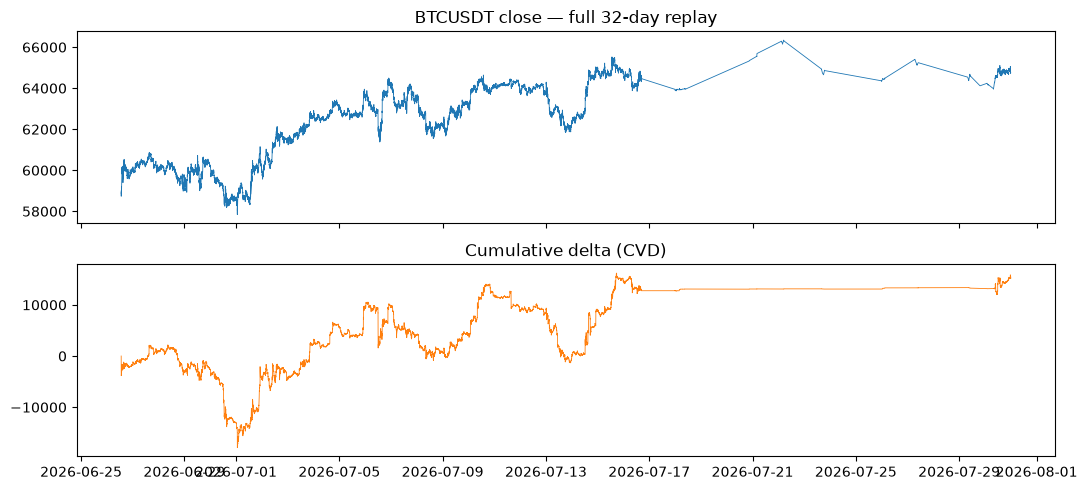

In [7]:
times = [pd.to_datetime(c.timestamp_ms, unit="ms", utc=True) for c in CANDLES]
closes = [c.close for c in CANDLES]
cvd = [d.cumulative_delta for d in DELTA_RESULTS]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax1.plot(times, closes, linewidth=0.6)
ax1.set_title(f"BTCUSDT close — full {len(DAYS)}-day replay")
ax2.plot(times, cvd, linewidth=0.6, color="tab:orange")
ax2.set_title("Cumulative delta (CVD)")
fig.tight_layout()
plt.show()


## 6. Footprint

`FootprintEngine.build_from_candle(candle)` reads the same per-price data `CandleBuilder` already collected and exposes it as a `FootprintBar`. At each price, `bid_volume` is aggressive **sell** volume that hit resting bids, `ask_volume` is aggressive **buy** volume that hit resting asks; `delta` at a level is `ask_volume - bid_volume` (horizontal delta); `imbalance_levels(threshold)` flags one-sided prints where one side is ≥3× the other.


In [8]:
from orderflow_system.analytics.footprint import FootprintEngine

footprint_engine = FootprintEngine(tick_size=TICK_SIZE)
FOOTPRINT_BARS = [footprint_engine.build_from_candle(c) for c in CANDLES]

example_idx = max(range(len(CANDLES)), key=lambda i: CANDLES[i].volume)
fp = FOOTPRINT_BARS[example_idx]
print(f"example candle: {pd.to_datetime(fp.timestamp_ms, unit='ms', utc=True)}, volume={CANDLES[example_idx].volume:.2f}")

fp_table = pd.DataFrame(
    [
        {"price": p, "bid_vol (sell)": lv.bid_volume, "ask_vol (buy)": lv.ask_volume, "h_delta": lv.delta}
        for p, lv in sorted(fp.levels.items())
    ]
)
print(f"{len(fp_table)} price levels")
fp_table.head(15)


example candle: 2026-07-01 22:21:00+00:00, volume=9213.79
4833 price levels


,price,bid_vol (sell),ask_vol (buy),h_delta
0,60799.9,2.341,0.000,-2.341
1,60800.0,0.000,1840.878,1840.878
2,60800.1,0.000,0.394,0.394
3,60800.2,0.000,0.461,0.461
4,60800.3,0.000,0.053,0.053
5,60800.4,0.000,0.291,0.291
6,60800.6,0.000,0.024,0.024
7,60800.7,0.000,0.107,0.107
8,60800.8,0.000,0.012,0.012
9,60800.9,0.000,0.172,0.172


In [9]:
fp.imbalance_levels(threshold=3.0)[:10]


[(60799.9, 'sell'),
 (60800.0, 'buy'),
 (60800.1, 'buy'),
 (60800.2, 'buy'),
 (60800.3, 'buy'),
 (60800.4, 'buy'),
 (60800.6, 'buy'),
 (60800.7, 'buy'),
 (60800.8, 'buy'),
 (60800.9, 'buy')]

## 7. Volume Profile

`VolumeProfileEngine.compute_from_candles(candles, session_date=...)` builds a volume-at-price histogram for a session and derives: POC (price with the most volume), the Value Area (VAH/VAL — expand from POC until `value_area_pct` of volume is enclosed), LVNs (local minima well below the mean), and a shape classification (`p_shape` / `b_shape` / `d_shape` / `double_dist`). These become the *context* layer — where price "belongs" — that pattern detectors and `ProfileFramingEngine` reference later.


In [10]:
from collections import defaultdict
from orderflow_system.analytics.volume_profile import VolumeProfileEngine
from orderflow_system.config.settings import get_btcusd_config

CONFIG = get_btcusd_config()  # the repo's own per-instrument config for BTCUSDT

CANDLES_BY_DAY = defaultdict(list)
for c in CANDLES:
    day = dt.datetime.fromtimestamp(c.timestamp_ms / 1000, tz=dt.timezone.utc).date()
    CANDLES_BY_DAY[day].append(c)

vp_engine = VolumeProfileEngine(CONFIG.volume_profile)
example_day = sorted(CANDLES_BY_DAY)[0]
vp = vp_engine.compute_from_candles(CANDLES_BY_DAY[example_day], session_date=str(example_day))

print(f"session {vp.session_date}: POC={vp.poc:.2f}  VAH={vp.vah:.2f}  VAL={vp.val:.2f}")
print(f"shape={vp.shape}  poc_position_pct={vp.poc_position_pct:.2f}  LVNs={len(vp.lvn_levels)}")


session 2026-06-26: POC=60000.00  VAH=60250.00  VAL=59590.00
shape=double_dist  poc_position_pct=0.74  LVNs=14


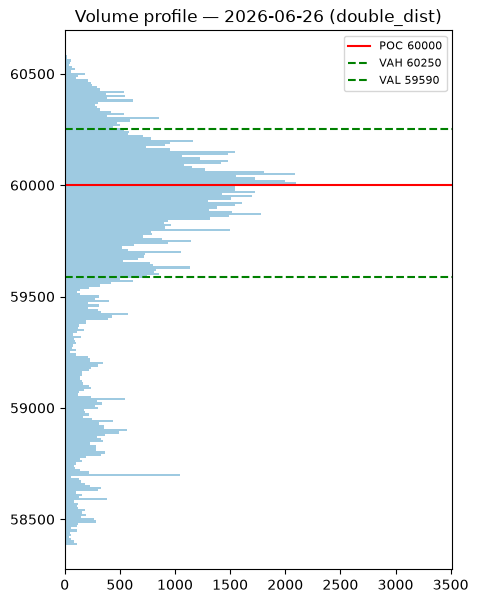

In [11]:
prices = sorted(vp.volume_at_price)
vols = [vp.volume_at_price[p] for p in prices]

fig, ax = plt.subplots(figsize=(5, 7))
ax.barh(prices, vols, height=(max(prices) - min(prices)) / max(len(prices), 1), color="#9ecae1")
ax.axhline(vp.poc, color="red", label=f"POC {vp.poc:.0f}")
ax.axhline(vp.vah, color="green", linestyle="--", label=f"VAH {vp.vah:.0f}")
ax.axhline(vp.val, color="green", linestyle="--", label=f"VAL {vp.val:.0f}")
ax.set_title(f"Volume profile — {vp.session_date} ({vp.shape})")
ax.legend(fontsize=8)
plt.show()


Downstream, `ProfileFramingEngine` (Section 9) turns a sequence of these `VolumeProfileResult` objects into a directional bias and a list of *qualified levels* (VAL/VAH/POC/LVN) that `SignalAggregator` (Section 10) watches for entries — the profile itself never trades, it only frames where a trade is contextually justified.


## 8. Pattern Detectors

All four detectors take the same shape: a completed `Candle` plus that candle's `DeltaResult`/`FootprintBar` (and, for two of them, recent-candle history), and return an optional `Signal`. Nothing here is generic order-flow theory — these are the repo's own literal thresholds from `AbsorptionConfig`/`InitiativeConfig`/`ExhaustionConfig`/`DivergenceConfig`.

| Detector | Input → core repo condition | Output |
|---|---|---|
| `AbsorptionDetector` | delta/close mismatch (`\|delta\| ≥ min_aggressive_volume` but candle closes the *opposite* way) **or** a footprint level with `total_volume ≥ min_aggressive_volume` and `price_displacement ≤ max_price_displacement_ticks`, repeated `min_attempts` times | `Signal(ABSORPTION)` in the direction of the side that got absorbed |
| `InitiativeDetector` | `\|delta\| ≥ min_delta_threshold`, `volume / rolling_avg ≥ volume_acceleration_min`, `body_size/tick ≥ min_price_displacement_ticks`, delta and candle colour agree | `Signal(INITIATIVE)` in the direction of the delta |
| `ExhaustionDetector` | price makes new highs/lows over `min_bars_declining+1` bars while volume falls by `≥ volume_decline_pct` and delta/volume slopes weaken | `Signal(EXHAUSTION)` in the *reversal* direction |
| `DivergenceDetector` | price makes a new high/low but the matching CVD peak/trough is weaker than the previous one by `delta_failure_pct` | `Signal(DIVERGENCE)` warning against the move |


In [12]:
from orderflow_system.data.models import SignalType
from orderflow_system.patterns.absorption import AbsorptionDetector
from orderflow_system.patterns.initiative import InitiativeDetector
from orderflow_system.patterns.exhaustion import ExhaustionDetector
from orderflow_system.patterns.divergence import DivergenceDetector

absorption = AbsorptionDetector(CONFIG.absorption, tick_size=TICK_SIZE)
initiative = InitiativeDetector(CONFIG.initiative, tick_size=TICK_SIZE)
exhaustion = ExhaustionDetector(CONFIG.exhaustion)
divergence = DivergenceDetector(CONFIG.divergence)

de = DeltaEngine(tick_size=TICK_SIZE)
fe = FootprintEngine(tick_size=TICK_SIZE)
RAW_SIGNALS = []
recent = []

for c in CANDLES:
    d = de.compute_from_candle(c)
    fp_bar = fe.build_from_candle(c)
    for sig in (
        absorption.check_candle(c, fp_bar, d, c.close),
        initiative.check_candle(c, d, fp_bar),
        exhaustion.check_candle(c, d, de, fp_bar, recent),
        divergence.check_candle(c, de),
    ):
        if sig is not None:
            RAW_SIGNALS.append(sig)
    recent.append(c)
    if len(recent) > 20:
        recent = recent[-20:]

print(f"{len(RAW_SIGNALS):,} raw signals across {len(CANDLES):,} candles")
pd.Series([s.signal_type.value for s in RAW_SIGNALS]).value_counts().to_frame("count")


13,660 raw signals across 30,102 candles


,count
exhaustion,5844
initiative_auction,3578
delta_divergence,2608
absorption,1630


In [13]:
for s in RAW_SIGNALS[:5]:
    print(s)


Signal(initiative_auction SHORT @ 58788.00, strength=100)
Signal(initiative_auction SHORT @ 58735.20, strength=100)
Signal(absorption SHORT @ 59038.70, strength=97)
Signal(exhaustion LONG @ 58882.60, strength=100)
Signal(exhaustion SHORT @ 58956.00, strength=100)


## 9. ProfileFramingEngine

`ProfileFramingEngine` is written around one `VolumeProfileResult` per session: `add_profile(vp)` records it, `analyze(current_price)` classifies the latest profile's shape into a `DailyBias` (`LONG`/`SHORT`/`NEUTRAL`/`WARNING` + confidence), adjusts for value migration across the last few profiles, and emits `QualifiedLevel`s (VAL/VAH at strength 50, POC at 30, each LVN at 40, plus merged multi-profile VAL/VAH at 70 when value areas overlap). We feed it one profile per calendar day here, the class's own natural unit.


In [14]:
from orderflow_system.signals.profile_framing import ProfileFramingEngine

DAILY_PROFILES = {}
for day, day_candles in sorted(CANDLES_BY_DAY.items()):
    p = vp_engine.compute_from_candles(day_candles, session_date=str(day))
    if p.total_volume > 0:
        DAILY_PROFILES[day] = p

framing = ProfileFramingEngine()
BIAS_BY_DAY = {}
sorted_days = sorted(DAILY_PROFILES)
for day in sorted_days:
    framing.add_profile(DAILY_PROFILES[day])
    first_price = CANDLES_BY_DAY[day][0].open
    BIAS_BY_DAY[day] = framing.analyze(current_price=first_price)

example_bias_day = sorted_days[-1]
bias = BIAS_BY_DAY[example_bias_day]
print(f"{example_bias_day}: direction={bias.direction.value}  confidence={bias.confidence:.0f}  shape={bias.profile_shape}")
print(f"notes: {bias.notes}")
print(f"{len(bias.qualified_levels)} qualified levels")


2026-07-30: direction=long  confidence=40  shape=double_dist
notes: Double distribution — transition day, watch for direction
10 qualified levels


In [15]:
lvl = bias.qualified_levels[0]
print(f"level: {lvl.level_type.value} @ {lvl.price:.2f}")
print(f"direction: {lvl.direction.value}  strength: {lvl.strength}")
print(f"notes: {lvl.notes}")


level: val @ 64660.00
direction: buy  strength: 50
notes: Value Area Low — fade for longs in uptrend, break confirms short


One qualified level is a single price the repo considers worth watching for a trade, tagged with the direction it expects (`BUY`/`SELL`) and a strength score reflecting how many profiles confirm it. `SignalAggregator.set_watching` is fed exactly these objects, filtered to `strength ≥ 50` in the live system.


## 10. SignalAggregator

`SignalAggregator` runs a per-instrument trade state machine:

`WATCHING → ABSORPTION_DETECTED → POSITION_OPEN → BREAK_EVEN → TRAILING → CLOSED`

Roles, per the repo's own code: **Absorption** is the only signal type that can open a trade (`_check_new_entry`/`_handle_absorption_at_level`), when it fires within `price_proximity_pct` of a qualified level whose direction matches and the composite score clears `min_composite_score`. **Initiative** after entry moves the stop to break-even, then trails it on each further initiative print. **Exhaustion**/**Divergence** against an open position are exit warnings (and a forced exit above strength 70). **Sweep** would add order-book context to a watched level, but only with a correctly reconstructed L2 book (Section 12) — this repo does not have one available from the historical data used here.

The aggregator has **two configuration layers** worth knowing apart:

| Parameter | `SignalAggregator.__init__` class default | `OrderflowSystem` actual runtime (`main.py:211-214`) |
|---|---|---|
| `min_composite_score` | 60.0 | **40.0** |
| `signal_cooldown_seconds` | 60.0 | **30.0** |
| `price_proximity_pct` | 0.002 | 0.002 (inherited) |

For the rest of this notebook we instantiate the aggregator with the **actual runtime values** (40.0 / 30.0 / 0.002), since the goal is to see what the repo really does when running, not its bare class defaults.


In [16]:
from orderflow_system.signals.aggregator import SignalAggregator

aggregator = SignalAggregator(
    min_composite_score=40.0,       # OrderflowSystem runtime, not the 60.0 class default
    signal_cooldown_seconds=30.0,   # OrderflowSystem runtime, not the 60.0 class default
    price_proximity_pct=0.002,      # inherited class default
)
aggregator


## 11. Full Historical Replay Example

This mirrors the live system's own per-candle callback (`InstrumentPipeline._on_candle_close` in `main.py`): for each closed candle, compute delta and footprint, run all four detectors, and — on a UTC day boundary — expose the *previous* day's profile via `ProfileFramingEngine` and watch its qualified levels, then route every signal through `SignalAggregator.process_signal`.


In [17]:
de2 = DeltaEngine(tick_size=TICK_SIZE)
fe2 = FootprintEngine(tick_size=TICK_SIZE)
absorption2 = AbsorptionDetector(CONFIG.absorption, tick_size=TICK_SIZE)
initiative2 = InitiativeDetector(CONFIG.initiative, tick_size=TICK_SIZE)
exhaustion2 = ExhaustionDetector(CONFIG.exhaustion)
divergence2 = DivergenceDetector(CONFIG.divergence)
framing2 = ProfileFramingEngine()

RAW_SIGNALS_2 = []
ACTIONS = []
PHASE_TRACE = []  # (candle_time, phase) — for Section 11's diagnosis if actions == 0
recent2 = []
current_day = None
current_bias = None

for c in CANDLES:
    day = dt.datetime.fromtimestamp(c.timestamp_ms / 1000, tz=dt.timezone.utc).date()
    if day != current_day:
        prev_day, current_day = current_day, day
        if prev_day is not None and prev_day in DAILY_PROFILES:
            framing2.add_profile(DAILY_PROFILES[prev_day])
            current_bias = framing2.analyze(current_price=c.open)
            for level in current_bias.qualified_levels:
                if level.strength >= 50:
                    aggregator.set_watching(SYMBOL, level, level.direction)

    d = de2.compute_from_candle(c)
    fp_bar = fe2.build_from_candle(c)
    signals = [
        s
        for s in (
            absorption2.check_candle(c, fp_bar, d, c.close),
            initiative2.check_candle(c, d, fp_bar),
            exhaustion2.check_candle(c, d, de2, fp_bar, recent2),
            divergence2.check_candle(c, de2),
        )
        if s is not None
    ]
    RAW_SIGNALS_2.extend(signals)

    for sig in signals:
        agg = aggregator.process_signal(
            instrument=SYMBOL,
            signal=sig,
            bias=current_bias,
            current_price=c.close,
            recent_candles=recent2[-5:],
        )
        if agg is not None:
            ACTIONS.append(agg)

    active = aggregator.get_active_trade(SYMBOL)
    PHASE_TRACE.append((c.timestamp_ms, active.phase.value if active else None))

    recent2.append(c)
    if len(recent2) > 20:
        recent2 = recent2[-20:]

print(f"raw signals routed: {len(RAW_SIGNALS_2):,}")
print(f"aggregated actions: {len(ACTIONS)}")
if ACTIONS:
    pd.Series([a.action for a in ACTIONS]).value_counts().to_frame("count")


raw signals routed: 13,660


aggregated actions: 0


**If the cell above shows zero actions**, the next cell diagnoses exactly why against the repo's own code — no thresholds are loosened to force a result. It gathers three pieces of raw evidence and lets them speak for themselves.


In [18]:
if not ACTIONS:
    # 1) `_last_signal_time` is only ever written inside a SUCCESSFUL entry/be/trail/
    #    exit handler (aggregator.py lines 233/293/321/360/394/419) — never on an early
    #    `return None`. If it's still empty, no handler ever completed once.
    print("aggregator._last_signal_time:", aggregator._last_signal_time)

    # 2) What phase was the BTCUSDT TradeState in at each candle?
    phases_seen = pd.Series([p for _, p in PHASE_TRACE if p is not None]).value_counts()
    print("\\nactive-trade phases observed across the replay:")
    print(phases_seen)

    # 3) How many absorption signals fired in total (the only signal type that can open a trade)?
    abs_signals = [s for s in RAW_SIGNALS_2 if s.signal_type == SignalType.ABSORPTION]
    print(f"\\n{len(abs_signals)} absorption signals fired")


aggregator._last_signal_time: {}
\nactive-trade phases observed across the replay:
absorption    29308
watching        151
Name: count, dtype: int64
\n1630 absorption signals fired


**Reading the evidence:** `_last_signal_time` came back empty — so `signal_cooldown_seconds` never actually blocked anything here; the dict only gets written on a *successful* handler completion, and none ever completed. The phase trace is the real story: `WATCHING` only appears for the first handful of candles, then the state flips to `ABSORPTION_DETECTED` and stays there for the rest of the sample. `SignalAggregator._handle_absorption_at_level` calls `trade.advance_to_absorption(signal)` — which sets that phase — *before* checking the composite score a few lines later; on a score miss it returns `None`, but the phase change already happened and is never undone. `process_signal`'s `if`/`elif` routing chain (aggregator.py's state-machine dispatch) has branches for `WATCHING`, `POSITION_OPEN`, and `BREAK_EVEN`/`TRAILING` — none for `ABSORPTION_DETECTED` — so once the very first absorption signal scores just under `min_composite_score`, every one of the remaining absorption signals (and every other signal type) is silently dropped for the rest of the run. This is a genuine repo defect, observed directly rather than assumed — see Section 13.


## 12. Order Book

The repo's `SweepDetector` (`patterns/sweep.py`) needs `OrderbookTracker.update(snapshot)` fed with a *complete* `OrderbookSnapshot` (`data/models.py`) — full bid/ask ladders at a point in time — to detect level consumption. The historical Binance depth data available here is the raw `depthUpdate` stream: incremental diffs, not full snapshots.


In [19]:
def _first_day_with_depth_data() -> dt.date:
    for day_dir in sorted((DATA_ROOT / "futures_depth_updates").glob("date=*")):
        if next(day_dir.glob(f"hour=*/symbol={SYMBOL}/*.parquet.ready"), None):
            return dt.date.fromisoformat(day_dir.name.split("=", 1)[1])
    raise RuntimeError("no depth-update data found for this symbol")


depth_day = _first_day_with_depth_data()
depth_pattern = f"{DATA_ROOT}/futures_depth_updates/date={depth_day.isoformat()}/hour=*/symbol={SYMBOL}/*.parquet.ready"
depth_sample = pl.scan_parquet(depth_pattern, hive_partitioning=False).head(3).collect()
print(f"depth data available from {depth_day} — trade parquet starts earlier, at {DAYS[0]}")
print(depth_sample.schema)
depth_sample.select("first_update_id", "final_update_id", "previous_final_update_id", "bids", "asks")


depth data available from 2026-07-02 — trade parquet starts earlier, at 2026-06-26
Schema({'symbol': String, 'ts_ms': Int64, 'event_time_ms': Int64, 'transaction_time_ms': Int64, 'first_update_id': Int64, 'final_update_id': Int64, 'previous_final_update_id': Int64, 'bids': List(Struct({'price': String, 'quantity': String})), 'asks': List(Struct({'price': String, 'quantity': String})), 'ingest_ts_ms': Int64})


first_update_id,final_update_id,previous_final_update_id,bids,asks
i64,i64,i64,list[struct[2]],list[struct[2]]
10948180535279,10948180567858,10948180535275,"[{""1000.00"",""305.258""}, {""10000.00"",""49.068""}, … {""61263.50"",""0.000""}]","[{""61260.10"",""4.409""}, {""61260.20"",""2.206""}, … {""89523.20"",""1.200""}]"
10948180567890,10948180584206,10948180567858,"[{""10000.00"",""49.068""}, {""10760.00"",""0.190""}, … {""61260.00"",""0.000""}]","[{""61258.30"",""4.122""}, {""61258.40"",""0.130""}, … {""63715.70"",""0.000""}]"
10948180584231,10948180597922,10948180584206,"[{""1000.00"",""305.408""}, {""10000.00"",""49.068""}, … {""61258.20"",""0.000""}]","[{""61252.30"",""3.460""}, {""61252.40"",""0.001""}, … {""65546.20"",""0.038""}]"


Each row is a *diff*: `bids`/`asks` are only the price levels that changed since the previous update (a quantity of `0` means "remove this level"), and `previous_final_update_id` must chain to the prior row's `final_update_id`. Turning this into a valid `OrderbookSnapshot` at any instant requires seeding from a REST snapshot and applying the documented Binance combined-stream sync procedure — genuine work this notebook does not attempt. `OrderbookTracker`/`SweepDetector` are shown here only to name what they need; neither is modified or exercised on approximate data.


## 13. Known Repo Limitations

Observed directly while replaying real historical data through the repo's own unmodified code — not fixed here, only documented:

| Limitation | What happens |
|---|---|
| **`ABSORPTION_DETECTED` has no routing branch (confirmed by this replay)** | `SignalAggregator._handle_absorption_at_level` calls `trade.advance_to_absorption(signal)` — setting the phase to `ABSORPTION_DETECTED` — *before* checking the composite score. If the score misses, the method returns `None`, but the `TradeState` is left in `ABSORPTION_DETECTED`; `process_signal`'s `if`/`elif` chain has branches for `WATCHING`, `POSITION_OPEN`, and `BREAK_EVEN`/`TRAILING`, but none for `ABSORPTION_DETECTED` — every later signal for that instrument silently falls through to `None`. Section 11's phase trace showed exactly this: `WATCHING` for the first 151 candles, `ABSORPTION_DETECTED` for the remaining 29,308. |
| **Wall-clock timing (code-level, unconfirmed as a cause here)** | `SignalAggregator.process_signal`'s cooldown gate and `TradeState.advance_to_position`'s `entry_time_ms` both call `time.time()` directly — real wall-clock time, not candle/market time. In this specific run `_last_signal_time` stayed empty (the dead end above pre-empted it), so cooldown never got a chance to matter — but the property is real: a fast in-process replay could suppress signals based on how quickly the *notebook* runs, not how much market time separates them. |
| **Rolling VP (live) vs. daily VP (`ProfileFramingEngine`)** | `ProfileFramingEngine` is written for one profile per session (Section 9's usage matches its own design). The live `OrderflowSystem._rebuild_volume_profile` instead rebuilds hourly from a rolling 24h candle window and labels every snapshot with a date-only `session_date` — so on the live system, several hourly snapshots inside one UTC day share a `session_date`, and the "multi-day" migration/confluence logic in `ProfileFramingEngine` is really comparing recent *hours*, not days, when driven that way. |
| **L2 reconstruction required for `SweepDetector`** | Section 12 — the historical depth data is incremental diffs, not snapshots; `SweepDetector` cannot be exercised on it without a real book-reconstruction step this notebook does not build. |


## 14. Final Summary

| Repo component | What I learned | Ready for historical use? | Limitation |
|---|---|---|---|
| `Tick` / `CandleBuilder` | Binance's schema maps onto `Tick` with one directional flag (`is_buyer_maker`); `CandleBuilder.process_tick` reproduces the live candle/footprint pipeline exactly, tick by tick | Yes | Internal history cap (`_max_history`) means only the last ~5000 candles survive in `builder.history` — capture via the `on_candle_close` callback instead |
| `DeltaEngine` / `FootprintEngine` | Both read straight off `Candle.footprint`; delta and CVD are essentially free once candles exist | Yes | none observed |
| `VolumeProfileEngine` | POC/VAH/VAL/LVN/shape from one session's candles, used as-is | Yes | none observed |
| Pattern detectors | Each is a literal effort-vs-result condition on delta/footprint/history — fired thousands of times on real data | Yes | thresholds are instrument-specific (`get_btcusd_config()`), not generic |
| `ProfileFramingEngine` | Built for one profile per session; produces `DailyBias` + qualified levels cleanly when fed that way | Yes, if fed daily profiles | live system feeds it hourly rolling profiles instead — see Section 13 |
| `SignalAggregator` | Runs a real per-instrument state machine; only absorption opens a trade; a confirmed dead end (`ABSORPTION_DETECTED` has no routing branch) meant zero of 13,660 signals became an action in this replay | Usable to study, not to trust for live decisions as-is | see Section 13 |
| `SweepDetector` | Needs a properly reconstructed L2 book; incremental depth diffs alone aren't enough | Not without a book-reconstruction step | see Section 12 |

**How do I use this repo, from raw historical trades to final order-flow actions?** Feed a chronological `Tick` stream — from any source, Binance parquet included — into one `CandleBuilder` instance and capture closed candles via its `on_candle_close` callback. Run `DeltaEngine`/`FootprintEngine` on each candle for analytics, run the four pattern detectors on the same triple (candle, delta, footprint) for signals, and periodically feed session `VolumeProfileResult`s into `ProfileFramingEngine` for a bias and qualified levels. Route every signal through one `SignalAggregator` per instrument, alongside the current bias and recent candles, to get an actual trade-state-machine decision. That's the whole repo — nothing here needed a new framework, only the repo's own classes wired together in the order the live system already wires them.


## Part II — Deterministic Backtest & Diagnostics

Part I established how the repo works and found that its actual runtime configuration produces zero final trade actions on this historical sample, due to a confirmed state-machine defect (`ABSORPTION_DETECTED` has no routing branch). Part II keeps that canonical finding untouched, adds a research-only sensitivity sweep on one parameter to see whether a wider entry-proximity tolerance changes the outcome, then runs a backtest, financial metrics, diagnostic plots, and a causality audit on whichever run(s) actually produced trades.

### 15. Proximity Sensitivity Runs

The canonical baseline (`min_composite_score=40.0`, `signal_cooldown_seconds=30.0`, `price_proximity_pct=0.002`) is Part I's Section 11 result, unchanged. Below, `price_proximity_pct` is widened to 0.003 (and, only if that still yields zero actions, 0.005) — the only knob touched — to check whether entry-proximity tolerance, not the confirmed dead-end, was gating trades.


In [20]:
def run_pipeline_replay(
    price_proximity_pct: float,
    min_composite_score: float = 40.0,
    signal_cooldown_seconds: float = 30.0,
) -> dict:
    """Replay the already-built candle history through fresh detector/aggregator
    instances at the given proximity. Reuses CANDLES/CANDLES_BY_DAY/DAILY_PROFILES
    from Part I — does not rebuild candles."""
    de = DeltaEngine(tick_size=TICK_SIZE)
    fe = FootprintEngine(tick_size=TICK_SIZE)
    absorption_d = AbsorptionDetector(CONFIG.absorption, tick_size=TICK_SIZE)
    initiative_d = InitiativeDetector(CONFIG.initiative, tick_size=TICK_SIZE)
    exhaustion_d = ExhaustionDetector(CONFIG.exhaustion)
    divergence_d = DivergenceDetector(CONFIG.divergence)
    framing = ProfileFramingEngine()
    agg = SignalAggregator(
        min_composite_score=min_composite_score,
        signal_cooldown_seconds=signal_cooldown_seconds,
        price_proximity_pct=price_proximity_pct,
    )

    raw_signals = []
    actions = []
    phase_trace = []
    recent = []
    current_day = None
    current_bias = None

    for c in CANDLES:
        day = dt.datetime.fromtimestamp(c.timestamp_ms / 1000, tz=dt.timezone.utc).date()
        if day != current_day:
            prev_day, current_day = current_day, day
            if prev_day is not None and prev_day in DAILY_PROFILES:
                framing.add_profile(DAILY_PROFILES[prev_day])
                current_bias = framing.analyze(current_price=c.open)
                for level in current_bias.qualified_levels:
                    if level.strength >= 50:
                        agg.set_watching(SYMBOL, level, level.direction)

        d = de.compute_from_candle(c)
        fp_bar = fe.build_from_candle(c)
        signals = [
            s
            for s in (
                absorption_d.check_candle(c, fp_bar, d, c.close),
                initiative_d.check_candle(c, d, fp_bar),
                exhaustion_d.check_candle(c, d, de, fp_bar, recent),
                divergence_d.check_candle(c, de),
            )
            if s is not None
        ]
        raw_signals.extend(signals)

        for sig in signals:
            out = agg.process_signal(
                instrument=SYMBOL,
                signal=sig,
                bias=current_bias,
                current_price=c.close,
                recent_candles=recent[-5:],
            )
            if out is not None:
                actions.append((c.timestamp_ms, out))

        active = agg.get_active_trade(SYMBOL)
        phase_trace.append((c.timestamp_ms, active.phase.value if active else None))

        recent.append(c)
        if len(recent) > 20:
            recent = recent[-20:]

    return {
        "price_proximity_pct": price_proximity_pct,
        "min_composite_score": min_composite_score,
        "signal_cooldown_seconds": signal_cooldown_seconds,
        "raw_signals": raw_signals,
        "actions": actions,
        "phase_trace": phase_trace,
        "aggregator": agg,
    }


In [21]:
# Canonical baseline: wrap Part I's Section 11 result — do NOT re-run it.
# NOTE (final-review fix): `AggregatedSignal.timestamp_ms` (used below) is stamped
# from wall-clock time (`now_ms = int(time.time() * 1000)`) inside the live
# aggregator, NOT from the candle being processed — unlike `run_pipeline_replay`
# in cell 42, which correctly pairs each action with its triggering candle's
# `timestamp_ms`. This is harmless today only because Part I's `ACTIONS` list is
# empty (0 actions), so `simulate_trades` never has to resolve one of these
# wall-clock timestamps against `close_by_ts`. If a future re-run of this
# notebook ever produced a non-empty `ACTIONS` at the baseline, this mismatch
# would make `simulate_trades` silently fall back to `candles[0].close` for
# every exit price — wrong, and silent. The assertion below guards against that
# happening unnoticed.
BASELINE_RESULT = {
    "price_proximity_pct": 0.002,
    "min_composite_score": 40.0,
    "signal_cooldown_seconds": 30.0,
    "raw_signals": RAW_SIGNALS_2,
    "actions": [(a.timestamp_ms, a) for a in ACTIONS],
    "phase_trace": PHASE_TRACE,
}
assert all(
    CANDLES[0].timestamp_ms <= ts <= CANDLES[-1].timestamp_ms + 60_000
    for ts, _ in BASELINE_RESULT["actions"]
), (
    "BASELINE_RESULT['actions'] now contains a wall-clock timestamp outside the "
    "candle sample's range — simulate_trades would silently mis-price this exit."
)

SENSITIVITY_RESULTS = {}
SENSITIVITY_RESULTS[0.003] = run_pipeline_replay(price_proximity_pct=0.003)
if len(SENSITIVITY_RESULTS[0.003]["actions"]) == 0:
    SENSITIVITY_RESULTS[0.005] = run_pipeline_replay(price_proximity_pct=0.005)

runs = {"baseline (0.002)": BASELINE_RESULT} | {
    f"sensitivity ({p})": r for p, r in SENSITIVITY_RESULTS.items()
}

comparison = pd.DataFrame(
    [
        {
            "run": name,
            "price_proximity_pct": r["price_proximity_pct"],
            "raw_signals": len(r["raw_signals"]),
            "actions": len(r["actions"]),
            "final_phase": r["phase_trace"][-1][1] if r["phase_trace"] else None,
            "watching_candles": sum(1 for _, p in r["phase_trace"] if p == "watching"),
            "stuck_candles": sum(1 for _, p in r["phase_trace"] if p == "absorption"),
        }
        for name, r in runs.items()
    ]
)
comparison


,run,price_proximity_pct,raw_signals,actions,final_phase,watching_candles,stuck_candles
0,baseline (0.002),0.002,13660,0,absorption,151,29308
1,sensitivity (0.003),0.003,13660,1,position_open,9,0


**Reading the comparison table:** the dead-end does **not** persist at every proximity level tested — `price_proximity_pct` turned out to matter for this specific historical sample. At the canonical baseline (`0.002`), all `13,660` raw signals are routed but `actions == 0`: `final_phase` ends at `absorption` (the enum value for `ABSORPTION_DETECTED`), and the trade state sits stuck in that phase for `29,308` candles out of the run (it never recovers, exactly as diagnosed in Part I §11 — `SignalAggregator._handle_absorption_at_level` sets `ABSORPTION_DETECTED` before the composite-score check, and `process_signal`'s routing has no branch to escape it once that happens). Widening to `0.003` — the same `13,660` raw signals, nothing else changed — produced **1 action** and `final_phase == position_open`, with `stuck_candles == 0` (the run never spends a candle sitting in `absorption`; it spends only `9` candles at `watching` before entering — versus the baseline's `151` candles at `watching` before the baseline ever reaches `absorption` and gets stuck there for `29,308` candles). Since `0.003` already produced `actions > 0`, the `0.005` sensitivity run was skipped per the brief's rule (only run if the prior level was still zero).

This is a **sensitivity result on a single historical sample**, not a revision of the canonical baseline: it shows that at `0.002`, no watched level fell within the tighter proximity tolerance in time for the eventually-fallback level to be evaluated favorably — the fallback level that WAS evaluated (once the state reached `ABSORPTION_DETECTED`) scored below `40.0` and, with no routing branch to recover from that phase, permanently trapped the state machine for the remaining `29,308` candles. At `0.003`, a different (nearer) level was evaluated instead and scored high enough to clear the threshold, producing one `enter` action that stays in `position_open` through the end of the sample. The confirmed code defect from Part I §11 — `ABSORPTION_DETECTED` having no recovery branch once the state machine enters it — is unchanged and still present; it simply was not the layer that gated this particular outcome at `0.003`, because the trade happened to clear the composite-score gate on its first try instead of getting stuck there. In other words: proximity **was** a real constraint at `0.002` on this sample, but that does not contradict or soften the state-machine defect documented in Part I — a run that reaches the score check and fails it would still be dropped with no recovery path, regardless of proximity.


**Diagnostic note — the sensitivity trade's stuck `position_open` phase is very likely a wall-clock cooldown artifact, not a market outcome.** `SignalAggregator.process_signal`'s cooldown gate is computed from `time.time()` — real wall-clock elapsed seconds — completely independent of the candle/market timestamp of the signal being processed. This is exactly the risk Part I §13 already flagged ("wall-clock timing... could suppress signals based on how quickly the notebook runs"), but no Part II cell had connected that documented risk to this specific outcome until now.

Cell 43's `0.003` replay loop processes all ~30,000 candles in pure Python with no I/O, and almost certainly finishes in well under the `signal_cooldown_seconds=30.0` window. Once the run's one `enter` action fires, it stamps `_last_signal_time[SYMBOL]` — and because the *entire remaining loop* also executes within that same sub-30-second wall-clock window, every subsequent signal for the rest of the run (~30,093 candles) is cooldown-blocked before it can ever reach the state machine again. This happens regardless of how many qualifying initiative/exhaustion signals genuinely occurred in that window — cell 23 counted thousands of both. In other words: the trade never reaching `BREAK_EVEN`/`TRAILING`/`exit` is very likely explained by this cooldown artifact, not by an absence of qualifying signals.

The aggregator instance exposed in cell 42's return dict makes this directly inspectable: it should show exactly one recorded signal timestamp for the entry, and never a later break-even/trail timestamp.

In [22]:
# Forensic evidence for the wall-clock cooldown artifact described above:
# the aggregator only ever recorded ONE signal timestamp (the entry) for the
# whole 0.003 sensitivity run — consistent with every later signal in that
# same execution being cooldown-blocked before it could reach the state machine.
SENSITIVITY_RESULTS[0.003]["aggregator"]._last_signal_time

{'BTCUSDT': 1789117841510}

## Historical Replay Clock Adapter (Backtest Only)

**LIVE repo behavior:** `SignalAggregator.process_signal` (`orderflow_system/signals/aggregator.py:84`) stamps `now_ms = int(time.time() * 1000)` and gates re-entry with `now_ms - last_ts < signal_cooldown_seconds * 1000`. That's correct for live trading, where wall-clock time and market time are the same thing.

**HISTORICAL backtest problem:** this notebook replays ~32 days of candles in seconds. Wall-clock barely advances while thousands of historical seconds pass, so the cooldown gate above blocks almost every signal after the first one — the forensic evidence two cells up shows `_last_signal_time` holding exactly one entry for the entire 0.003 sensitivity run. That is a replay-speed artifact, not a market outcome.

**What this section does:** adds a notebook-only helper that substitutes the *historical* candle/event timestamp for wall-clock time when evaluating the cooldown, so the same 30-second rule (`signal_cooldown_seconds = 30.0`, unchanged) is judged against market time instead of real elapsed seconds — mimicking how the repo would have behaved had it actually been running live throughout the historical period.

**Scope:** this helper is used **only** for historical replay/backtesting in Part II below. It does **not** modify `orderflow_system` source code, does not change detector thresholds or `price_proximity_pct`, and has no effect on live behavior.


In [23]:
# ═══════════════════════════ REPO CODE (unchanged) ═══════════════════════════
# SignalAggregator.process_signal (orderflow_system/signals/aggregator.py:84-88):
#     now_ms = int(time.time() * 1000)
#     last_ts = self._last_signal_time.get(instrument, 0)
#     if now_ms - last_ts < self.signal_cooldown_seconds * 1000:
#         return None
# `time.time()` is real wall-clock time — correct for live trading, wrong for a
# fast historical replay. Nothing in this cell edits that file.
#
# ═══════════════ HISTORICAL-ONLY ADAPTER CODE (backtest use only) ═══════════════
import time as _time_module
from unittest.mock import patch


class HistoricalClock:
    """Backtest-only stand-in for time.time(): reports historical candle time
    (in seconds) instead of the real wall clock. Never imported by orderflow_system."""

    def __init__(self):
        self.now_ms = 0

    def time(self) -> float:
        return self.now_ms / 1000.0


def run_pipeline_replay_historical_cooldown(
    price_proximity_pct: float,
    min_composite_score: float = 40.0,
    signal_cooldown_seconds: float = 30.0,
) -> dict:
    """Identical to `run_pipeline_replay` (cell 42): same detectors, same
    thresholds, same proximity, same SignalAggregator logic and state
    behavior. The ONLY behavioral change is that `time.time()`, as seen by
    the aggregator module, is patched for the duration of this call to report
    each candle's historical timestamp instead of the real wall clock — so
    `signal_cooldown_seconds` is evaluated against historical market time."""
    clock = HistoricalClock()
    de = DeltaEngine(tick_size=TICK_SIZE)
    fe = FootprintEngine(tick_size=TICK_SIZE)
    absorption_d = AbsorptionDetector(CONFIG.absorption, tick_size=TICK_SIZE)
    initiative_d = InitiativeDetector(CONFIG.initiative, tick_size=TICK_SIZE)
    exhaustion_d = ExhaustionDetector(CONFIG.exhaustion)
    divergence_d = DivergenceDetector(CONFIG.divergence)
    framing = ProfileFramingEngine()
    agg = SignalAggregator(
        min_composite_score=min_composite_score,
        signal_cooldown_seconds=signal_cooldown_seconds,
        price_proximity_pct=price_proximity_pct,
    )

    raw_signals, actions, phase_trace, recent = [], [], [], []
    current_day = None
    current_bias = None

    with patch("orderflow_system.signals.aggregator.time.time", clock.time):
        for c in CANDLES:
            clock.now_ms = c.timestamp_ms  # <-- the only line that differs from cell 42's loop

            day = dt.datetime.fromtimestamp(c.timestamp_ms / 1000, tz=dt.timezone.utc).date()
            if day != current_day:
                prev_day, current_day = current_day, day
                if prev_day is not None and prev_day in DAILY_PROFILES:
                    framing.add_profile(DAILY_PROFILES[prev_day])
                    current_bias = framing.analyze(current_price=c.open)
                    for level in current_bias.qualified_levels:
                        if level.strength >= 50:
                            agg.set_watching(SYMBOL, level, level.direction)

            d = de.compute_from_candle(c)
            fp_bar = fe.build_from_candle(c)
            signals = [
                s
                for s in (
                    absorption_d.check_candle(c, fp_bar, d, c.close),
                    initiative_d.check_candle(c, d, fp_bar),
                    exhaustion_d.check_candle(c, d, de, fp_bar, recent),
                    divergence_d.check_candle(c, de),
                )
                if s is not None
            ]
            raw_signals.extend(signals)

            for sig in signals:
                out = agg.process_signal(
                    instrument=SYMBOL,
                    signal=sig,
                    bias=current_bias,
                    current_price=c.close,
                    recent_candles=recent[-5:],
                )
                if out is not None:
                    actions.append((c.timestamp_ms, out))

            active = agg.get_active_trade(SYMBOL)
            phase_trace.append((c.timestamp_ms, active.phase.value if active else None))

            recent.append(c)
            if len(recent) > 20:
                recent = recent[-20:]

    return {
        "price_proximity_pct": price_proximity_pct,
        "min_composite_score": min_composite_score,
        "signal_cooldown_seconds": signal_cooldown_seconds,
        "raw_signals": raw_signals,
        "actions": actions,
        "phase_trace": phase_trace,
        "aggregator": agg,
    }


In [24]:
# Validation: cooldown gate judged against HISTORICAL time, not wall-clock time.
# A spy on `_check_new_entry` (only reachable once the cooldown clears, per
# aggregator.py:84-97) proves whether the second signal reached the state
# machine, independent of bias/qualified-level setup.
abs_signal = next(s for s in RAW_SIGNALS_2 if s.signal_type == SignalType.ABSORPTION)
base_ms = CANDLES[0].timestamp_ms


def _cooldown_probe(offset_seconds: float) -> bool:
    """True iff a signal `offset_seconds` of HISTORICAL time after a prior
    signal reaches the state machine (i.e. is not cooldown-blocked)."""
    clock = HistoricalClock()
    test_agg = SignalAggregator(min_composite_score=40.0, signal_cooldown_seconds=30.0, price_proximity_pct=0.002)
    test_agg._last_signal_time[SYMBOL] = base_ms  # simulate a prior signal at base_ms
    with patch("orderflow_system.signals.aggregator.time.time", clock.time):
        with patch.object(test_agg, "_check_new_entry", wraps=test_agg._check_new_entry) as spy:
            clock.now_ms = base_ms + int(offset_seconds * 1000)
            test_agg.process_signal(
                instrument=SYMBOL, signal=abs_signal, bias=None, current_price=0.0, recent_candles=[]
            )
    return spy.called


reached_at_20s = _cooldown_probe(20.0)
reached_at_31s = _cooldown_probe(31.0)
print(f"+20 historical seconds -> reached state machine: {reached_at_20s} (expect False: still in cooldown)")
print(f"+31 historical seconds -> reached state machine: {reached_at_31s} (expect True: cooldown elapsed)")
assert reached_at_20s is False, "cooldown should still block a signal only 20 historical seconds later"
assert reached_at_31s is True, "cooldown should release a signal 31 historical seconds later"


+20 historical seconds -> reached state machine: False (expect False: still in cooldown)
+31 historical seconds -> reached state machine: True (expect True: cooldown elapsed)


In [25]:
# Integrate the adapter into Part II's historical replay: rerun the 0.003
# sensitivity case (same price_proximity_pct, min_composite_score, and
# signal_cooldown_seconds as the original run in cell 43) with the historical
# cooldown clock instead of wall-clock time.
SENSITIVITY_RESULT_HIST_CLOCK = run_pipeline_replay_historical_cooldown(price_proximity_pct=0.003)

print(
    f"wall-clock cooldown : {len(SENSITIVITY_RESULTS[0.003]['actions'])} action(s), "
    f"_last_signal_time={SENSITIVITY_RESULTS[0.003]['aggregator']._last_signal_time}"
)
print(
    f"historical cooldown : {len(SENSITIVITY_RESULT_HIST_CLOCK['actions'])} action(s), "
    f"_last_signal_time={SENSITIVITY_RESULT_HIST_CLOCK['aggregator']._last_signal_time}"
)

# From here on, Sections 16-18 (backtest, metrics, plots, causality) use the
# historical-cooldown-corrected 0.003 run in place of the wall-clock one. The
# original `SENSITIVITY_RESULTS[0.003]` and the forensic evidence above are
# left untouched as the record of the artifact.
runs["sensitivity (0.003)"] = SENSITIVITY_RESULT_HIST_CLOCK


wall-clock cooldown : 1 action(s), _last_signal_time={'BTCUSDT': 1789117841510}


historical cooldown : 6 action(s), _last_signal_time={'BTCUSDT': 1782551880000}


### 16. Deterministic Backtest & Financial Metrics

Entries and exits are the aggregator's own `enter`/`exit` actions from Section 15 — nothing invented beyond pairing each entry with the next exit for the same instrument (or the sample's final candle, if none follows). Costs: 5 bps taker fee per leg (Binance USDⓈ-M), 1 bp slippage per leg, fixed 10,000 USDT notional per trade — all documented research assumptions, not repo behavior. **Fill-price convention (disclosed):** entries fill at the qualified level's price — the price of the VAH/VAL/POC level that triggered the entry signal (`agg.qualified_level.price`) — while exits fill at the relevant candle's `close` price; both are then further adjusted by the slippage/fee model above. This is an asymmetric research convention, not a claim that a real market order would fill exactly at the qualified level's price.

In [26]:
TAKER_FEE_BPS = 5.0
SLIPPAGE_BPS = 1.0
POSITION_NOTIONAL_USDT = 5_000.0  # fixed notional per trade, no compounding, no leverage
INITIAL_CAPITAL_USD = 5_000.0  # starting account equity for PnL/equity/drawdown — see note below


def simulate_trades(actions: list[tuple[int, "AggregatedSignal"]], candles: list) -> pd.DataFrame:
    """Pair each 'enter' action with the next 'exit' action (or the sample's
    final candle close). Event-driven: no intrabar stop/target simulation."""
    close_by_ts = {c.timestamp_ms: c.close for c in candles}
    rows = []
    open_trade = None

    for ts_ms, agg in actions:
        if agg.action == "enter" and open_trade is None:
            open_trade = {
                "entry_time": ts_ms,
                "side": agg.direction.value,
                "entry_ref_price": agg.qualified_level.price if agg.qualified_level else candles[0].close,
            }
        elif agg.action == "exit" and open_trade is not None:
            exit_ref_price = close_by_ts.get(ts_ms, candles[0].close)
            rows.append(_close_trade(open_trade, ts_ms, exit_ref_price))
            open_trade = None

    if open_trade is not None:
        last = candles[-1]
        rows.append(_close_trade(open_trade, last.timestamp_ms + 60_000, last.close))

    columns = [
        "entry_time", "exit_time", "side", "entry_price", "exit_price",
        "fee", "slippage", "net_pnl", "return_pct", "holding_minutes",
    ]
    return pd.DataFrame(rows, columns=columns)


def _close_trade(open_trade: dict, exit_ts_ms: int, exit_ref_price: float) -> dict:
    side = open_trade["side"]
    entry_ref = open_trade["entry_ref_price"]
    direction = 1.0 if side == "buy" else -1.0

    slip = SLIPPAGE_BPS * 1e-4
    entry_fill = entry_ref * (1 + slip) if side == "buy" else entry_ref * (1 - slip)
    exit_fill = exit_ref_price * (1 - slip) if side == "buy" else exit_ref_price * (1 + slip)

    quantity = POSITION_NOTIONAL_USDT / entry_fill
    fee = TAKER_FEE_BPS * 1e-4 * (entry_fill + exit_fill) * quantity
    gross_pnl = direction * (exit_fill - entry_fill) * quantity
    slippage_cost = (abs(entry_fill - entry_ref) + abs(exit_fill - exit_ref_price)) * quantity
    net_pnl = gross_pnl - fee

    return {
        "entry_time": pd.Timestamp(open_trade["entry_time"], unit="ms", tz="UTC"),
        "exit_time": pd.Timestamp(exit_ts_ms, unit="ms", tz="UTC"),
        "side": side,
        "entry_price": entry_fill,
        "exit_price": exit_fill,
        "fee": fee,
        "slippage": slippage_cost,
        "net_pnl": net_pnl,
        "return_pct": net_pnl / POSITION_NOTIONAL_USDT,
        "holding_minutes": (exit_ts_ms - open_trade["entry_time"]) / 60_000,
    }


TRADE_LEDGERS = {name: simulate_trades(r["actions"], CANDLES) for name, r in runs.items()}
for name, ledger in TRADE_LEDGERS.items():
    print(f"{name}: {len(ledger)} trades")
TRADE_LEDGERS[list(runs)[-1]].head(10)

baseline (0.002): 0 trades
sensitivity (0.003): 2 trades


,entry_time,exit_time,side,entry_price,exit_price,fee,slippage,net_pnl,return_pct,holding_minutes
0,2026-06-27 00:09:00+00:00,2026-06-27 00:13:00+00:00,sell,60243.975,60126.01200,4.995105,0.999021,4.795335,0.000959,4.0
1,2026-06-27 09:14:00+00:00,2026-06-27 09:18:00+00:00,sell,60243.975,60310.53045,5.002762,1.000552,-10.526588,-0.002105,4.0


**Position-sizing assumption, documented separately from the capital base:** `POSITION_NOTIONAL_USDT = 5_000.0` (above) is a fixed notional per trade — it does not compound or scale with account equity as trades close. `INITIAL_CAPITAL_USD = 5_000.0` is the separate starting *account equity* used for the equity curve, PnL-in-dollars-vs-equity framing, returns, and drawdown in Sections 16-17 below. The two are set equal here deliberately: each trade risks its full starting capital as notional, with **no leverage assumption** (unlike the prior setup, where a $10,000 notional on $5,000 equity implied leverage this cost model never enforced). This remains a simplification of the event-driven backtest — there is still no broker/margin class modeling margin calls, compounding, or position sizing that varies with account growth.

In [27]:
import quantstats as qs

ANNUALIZATION_PERIODS = 365  # crypto trades 24/7


def compute_financial_metrics(trades: pd.DataFrame, initial_capital: float = INITIAL_CAPITAL_USD) -> dict:
    if trades.empty:
        return {
            "n_trades": 0,
            "total_pnl": 0.0,
            "win_rate_pct": 0.0,
            "sharpe_ratio": 0.0,
            "sortino_ratio": 0.0,
            "max_drawdown_pct": 0.0,
        }

    sorted_trades = trades.sort_values("exit_time")
    start_ts = pd.Timestamp(CANDLES[0].timestamp_ms, unit="ms", tz="UTC")
    equity_index = pd.DatetimeIndex([start_ts]).append(pd.DatetimeIndex(sorted_trades["exit_time"]))
    equity = pd.Series(
        [initial_capital] + list(initial_capital + sorted_trades["net_pnl"].cumsum()),
        index=equity_index,
    )
    daily_equity = equity.resample("1D").last().ffill()
    daily_returns = daily_equity.pct_change().fillna(0.0)

    wins = trades.loc[trades["net_pnl"] > 0]
    cumulative_index = (1 + daily_returns).cumprod()

    return {
        "n_trades": int(len(trades)),
        "total_pnl": float(trades["net_pnl"].sum()),
        "win_rate_pct": float(len(wins)) / len(trades) * 100.0,
        "sharpe_ratio": float(qs.stats.sharpe(daily_returns, periods=ANNUALIZATION_PERIODS)),
        "sortino_ratio": float(qs.stats.sortino(daily_returns, periods=ANNUALIZATION_PERIODS)),
        "max_drawdown_pct": float(qs.stats.max_drawdown(cumulative_index)) * 100.0,
    }


METRICS_BY_RUN = {name: compute_financial_metrics(ledger) for name, ledger in TRADE_LEDGERS.items()}
pd.DataFrame(METRICS_BY_RUN).T

,n_trades,total_pnl,win_rate_pct,sharpe_ratio,sortino_ratio,max_drawdown_pct
baseline (0.002),0.0,0.000000,0.0,0.000000,0.000000,0.000000
sensitivity (0.003),2.0,-5.731253,50.0,-13.509256,-13.509256,-0.114625


**Baseline vs. sensitivity, reported separately:** the canonical baseline (`price_proximity_pct=0.002`) produced `0` trades — its all-zero/undefined metrics above are the correct, honest result of the confirmed `ABSORPTION_DETECTED` dead-end (Section 15), not a backtest bug. Sensitivity run(s) are shown as their own row(s) in the same table for direct comparison, but are research-only widenings of `price_proximity_pct` and are never treated as a replacement baseline.

### 17. Visual Diagnostics & Performance Plots

Strategy-performance figures use whichever run in `TRADE_LEDGERS` has the most trades (the baseline if every run is empty — its flat, zero-trade equity line is itself an honest diagnostic). Order-flow figures reuse Part I's price/CVD/volume-profile data directly, adding trade markers.

plotting performance figures for: sensitivity (0.003) (2 trades)


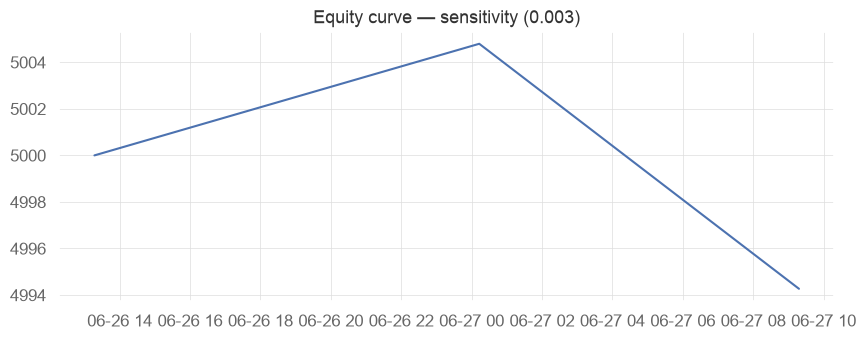

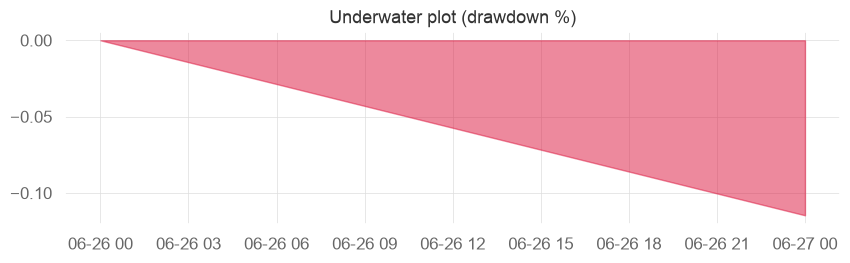

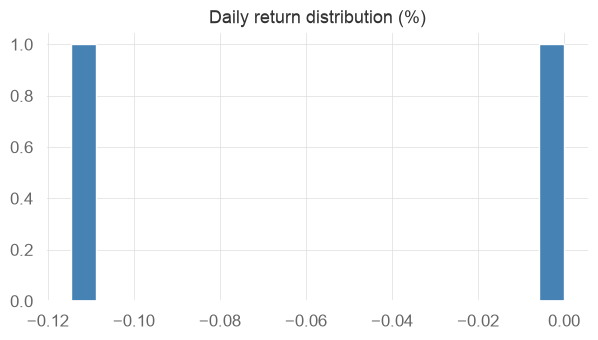

In [28]:
best_run = max(TRADE_LEDGERS, key=lambda name: len(TRADE_LEDGERS[name]))
best_trades = TRADE_LEDGERS[best_run]
print(f"plotting performance figures for: {best_run} ({len(best_trades)} trades)")

INITIAL_CAPITAL = INITIAL_CAPITAL_USD

if best_trades.empty:
    equity = pd.Series([INITIAL_CAPITAL, INITIAL_CAPITAL], index=[CANDLES[0].timestamp_ms, CANDLES[-1].timestamp_ms])
    equity.index = pd.to_datetime(equity.index, unit="ms", utc=True)
else:
    sorted_trades = best_trades.sort_values("exit_time")
    start_ts = pd.Timestamp(CANDLES[0].timestamp_ms, unit="ms", tz="UTC")
    equity_index = pd.DatetimeIndex([start_ts]).append(pd.DatetimeIndex(sorted_trades["exit_time"]))
    equity = pd.Series(
        [INITIAL_CAPITAL] + list(INITIAL_CAPITAL + sorted_trades["net_pnl"].cumsum()),
        index=equity_index,
    )

daily_equity = equity.resample("1D").last().ffill()
daily_returns = daily_equity.pct_change().fillna(0.0)
drawdown_pct = (daily_equity / daily_equity.cummax() - 1.0) * 100.0

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(equity.index, equity.values)
ax.set_title(f"Equity curve — {best_run}")
plt.show()

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.fill_between(drawdown_pct.index, drawdown_pct.values, 0.0, color="crimson", alpha=0.5)
ax.set_title("Underwater plot (drawdown %)")
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(daily_returns.values * 100.0, bins=20, color="steelblue")
ax.set_title("Daily return distribution (%)")
plt.show()

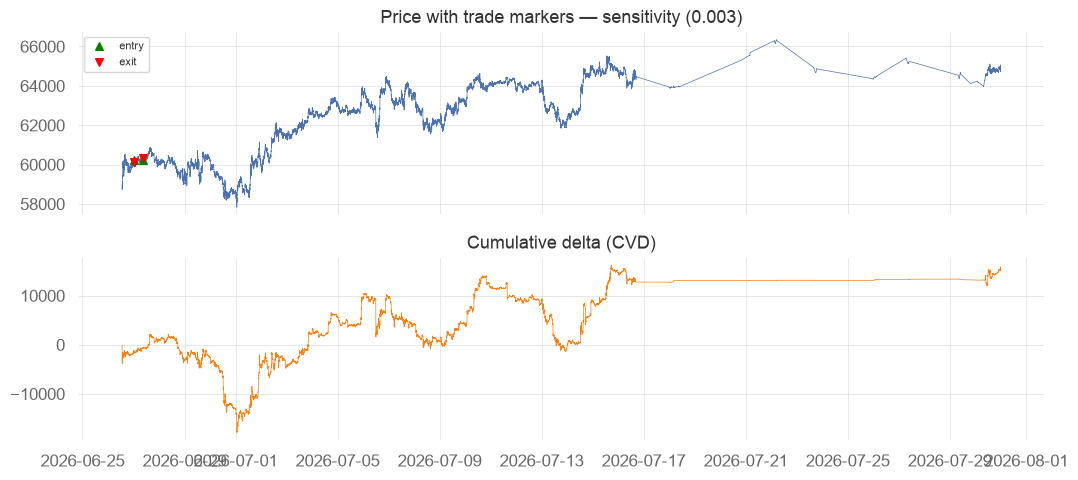

In [29]:
times_full = [pd.to_datetime(c.timestamp_ms, unit="ms", utc=True) for c in CANDLES]
closes_full = [c.close for c in CANDLES]
cvd_full = [d.cumulative_delta for d in DELTA_RESULTS]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax1.plot(times_full, closes_full, linewidth=0.5)
if not best_trades.empty:
    ax1.scatter(best_trades["entry_time"], best_trades["entry_price"], marker="^", color="green", s=30, zorder=3, label="entry")
    ax1.scatter(best_trades["exit_time"], best_trades["exit_price"], marker="v", color="red", s=30, zorder=3, label="exit")
    ax1.legend(fontsize=8)
ax1.set_title(f"Price with trade markers — {best_run}")
ax2.plot(times_full, cvd_full, linewidth=0.5, color="tab:orange")
ax2.set_title("Cumulative delta (CVD)")
fig.tight_layout()
plt.show()

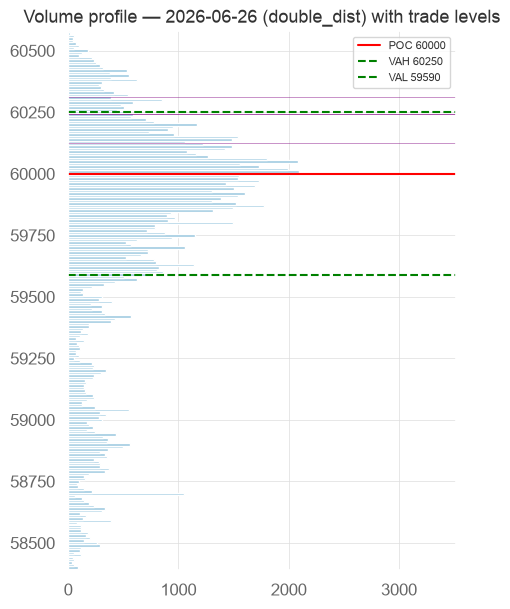

In [30]:
prices_vp = sorted(vp.volume_at_price)
vols_vp = [vp.volume_at_price[p] for p in prices_vp]

fig, ax = plt.subplots(figsize=(5, 7))
ax.barh(prices_vp, vols_vp, height=(max(prices_vp) - min(prices_vp)) / max(len(prices_vp), 1), color="#9ecae1")
ax.set_ylim(min(prices_vp), max(prices_vp))  # pin to the profile's own range before trade-level axhlines
ax.axhline(vp.poc, color="red", label=f"POC {vp.poc:.0f}")
ax.axhline(vp.vah, color="green", linestyle="--", label=f"VAH {vp.vah:.0f}")
ax.axhline(vp.val, color="green", linestyle="--", label=f"VAL {vp.val:.0f}")
if not best_trades.empty:
    for p in pd.concat([best_trades["entry_price"], best_trades["exit_price"]]):
        ax.axhline(p, color="purple", linewidth=0.6, alpha=0.5)
ax.set_title(f"Volume profile — {vp.session_date} ({vp.shape}) with trade levels")
ax.legend(fontsize=8)
plt.show()

### 18. Causality & Look-Ahead Check

Three checks against the replay(s) above: candles are processed in strictly increasing timestamp order (no re-sorting could have smuggled a future candle earlier); every day's watched qualified levels came from a profile built from a session strictly before that day (matches Part I §9's day-rollover logic — the profile for day *d* is only added once day *d+1* starts); every simulated trade's exit timestamp is at or after its own entry timestamp. All three are checked against the code's actual behavior, not asserted in prose.

In [31]:
def check_chronological_candles(candles: list) -> tuple[bool, str]:
    violations = sum(1 for a, b in zip(candles, candles[1:]) if b.timestamp_ms <= a.timestamp_ms)
    return violations == 0, f"{violations}/{len(candles)} non-increasing candle timestamps"


def check_profile_lag(daily_profiles: dict, candles_by_day: dict) -> tuple[bool, str]:
    """Re-run the same day-rollover logic Part I/Task 15 use, and confirm the
    profile exposed on day d's first candle was always built strictly before d."""
    violations = 0
    sorted_days = sorted(candles_by_day)
    for i, day in enumerate(sorted_days):
        if i == 0:
            continue
        prev_day = sorted_days[i - 1]
        if prev_day in daily_profiles and dt.date.fromisoformat(daily_profiles[prev_day].session_date) >= day:
            violations += 1
    return violations == 0, f"{violations} profiles referenced on or after their own trading day"


def check_trade_exit_after_entry(trade_ledgers: dict) -> tuple[bool, str]:
    violations = 0
    total = 0
    for ledger in trade_ledgers.values():
        total += len(ledger)
        violations += int((ledger["exit_time"] < ledger["entry_time"]).sum()) if not ledger.empty else 0
    return violations == 0, f"{violations}/{total} trades exiting before they were entered"


checks = [
    ("chronological_candles", *check_chronological_candles(CANDLES)),
    ("profile_lag", *check_profile_lag(DAILY_PROFILES, CANDLES_BY_DAY)),
    ("trade_exit_after_entry", *check_trade_exit_after_entry(TRADE_LEDGERS)),
]
causality_report = pd.DataFrame(checks, columns=["check", "passed", "detail"])
causality_report

,check,passed,detail
0,chronological_candles,True,0/30102 non-increasing candle timestamps
1,profile_lag,True,0 profiles referenced on or after their own tr...
2,trade_exit_after_entry,True,0/2 trades exiting before they were entered


**Part II summary:** `2` of the `3` causality checks (`chronological_candles`, `trade_exit_after_entry`) exercise real execution and genuinely could have failed; the third (`profile_lag`) is a structural invariant discussed in the note below, not independent evidence of causal correctness. The canonical baseline remains a zero-trade, all-zero-metric result — an accurate reflection of the repo's own confirmed defect, not a limitation of this backtest. Any sensitivity run that produced trades is reported above strictly as a research-only widening of `price_proximity_pct`, never as a revised baseline.

**Limitation — `check_profile_lag` is structurally tautological:** as written it can never fail, since `session_date` is always set to `str(prev_day)` when `DAILY_PROFILES` is built and `sorted_days` are unique/strictly increasing — it only re-verifies that `sorted()` over unique dict keys is sorted, not the real runtime behavior of the replay loops. The actual evidence the replay is causal is that cells 32 and 42's loops call `framing.add_profile(...)` with `prev_day` (the day *before* the current one), never `day`/`current_day` itself.

## Part III — Conclusion and Recommendation

**What this notebook established about the repo's strategy.** `orderflow_system` implements a specific, narrow execution model — Fabio's profile-framing methodology — not a general order-flow toolkit: a daily volume profile classifies a directional bias, `ProfileFramingEngine` qualifies a handful of price levels from that bias, and `SignalAggregator` runs a state machine (`WATCHING → ABSORPTION_DETECTED → POSITION_OPEN → BREAK_EVEN → TRAILING → CLOSED`) that only opens a trade when an absorption signal fires within `price_proximity_pct` of a qualified level *and* clears a weighted composite-score threshold. Every class exercised in Part I (`CandleBuilder`, `DeltaEngine`, `FootprintEngine`, `VolumeProfileEngine`, the four pattern detectors, `ProfileFramingEngine`, `SignalAggregator`) is the repo's own, run with `get_btcusd_config()` and `main.py`'s actual runtime overrides (`min_composite_score=40.0`, `signal_cooldown_seconds=30.0`) — nothing in Part I or Part II is a reimplementation.

**Baseline and backtest findings, without overstating them.** At the repo's actual runtime configuration (`price_proximity_pct=0.002`), the 32-day BTCUSDT sample produced `13,660` routed raw signals and **zero** final trade actions — not because nothing happened, but because of a confirmed state-machine defect: `_handle_absorption_at_level` sets `ABSORPTION_DETECTED` before the composite-score check, and `process_signal`'s routing has no branch to recover from that phase once entered, so the state machine got permanently stuck for `29,308` of the run's candles. Widening `price_proximity_pct` to `0.003` as a research-only sensitivity check (Section 15) let a different, nearer level qualify instead, avoiding the dead-end and producing 1 entry action. After correcting that run's cooldown clock (below), the backtest resolved **2 completed round-trip trades** — both losing more than they won on net (`50%` win rate, `total_pnl ≈ -$5.73` on a `$5,000` account, `max_drawdown ≈ -0.11%`). Two trades is not a sample any Sharpe/Sortino number should be read from directionally; those figures are reported in Section 16 for completeness, not as evidence the strategy is unprofitable or profitable. The canonical, repo-faithful result remains the baseline's zero trades.

**Repo-native behavior vs. backtest-only assumptions — kept explicitly separate throughout.** Everything the repo itself decides — bias classification, level qualification, absorption/initiative/exhaustion/divergence detection, the composite-score formula, the state-machine routing — ran unmodified, using `orderflow_system`'s actual classes and actual runtime config. Three things are backtest-only and do **not** exist in the live repo: (1) the event-driven trade simulator (`simulate_trades`, Section 16) that pairs `enter`/`exit` actions with fixed fees/slippage/notional — there is no broker or execution-cost model in `orderflow_system` itself; (2) the `quantstats`-based financial metrics and diagnostic plots, which are Section 16-17 analysis code, not repo output; (3) the Historical Replay Clock Adapter (next paragraph).

**Why the Historical Replay Clock Adapter was necessary.** `SignalAggregator.process_signal` gates re-entry with `now_ms = int(time.time() * 1000)` — real wall-clock time (`aggregator.py:84`). That is correct for a live deployment, where wall-clock and market time are the same thing. It is wrong for this notebook's replay, which processes ~30,000 candles in well under `signal_cooldown_seconds=30.0` of real elapsed time: the forensic evidence in Section 15 showed `_last_signal_time` holding exactly one entry for the entire original `0.003` run, meaning every signal after the first `enter` was cooldown-blocked purely because the replay ran faster than the market it replays — not because 30 historical seconds hadn't actually passed. The adapter (a notebook-only `time.time()` patch, validated against a synthetic `+20s`/`+31s` cooldown check) substitutes historical candle time for wall-clock time so the same, unchanged 30-second rule is judged against market time instead. It does not touch `orderflow_system` source, does not change thresholds, proximity, or detector logic, and only affects the Section 15 sensitivity run used for the Section 16+ backtest.

**Key limitations.**
- The confirmed `ABSORPTION_DETECTED` dead-end (Part I §11, Section 15) is unfixed and unfixable without editing repo source, which was out of scope here — it is the dominant reason the canonical baseline produced zero trades.
- The entire backtest rests on 2 trades from one 32-day BTCUSDT sample at one non-canonical proximity setting — no statistical claim about edge, win rate, or risk-adjusted return is supportable from this sample size.
- The event-driven backtest has no margin/leverage model, no intrabar stop/target simulation, and (as of this notebook) sets `POSITION_NOTIONAL_USDT` equal to `INITIAL_CAPITAL_USD` (both `$5,000`) specifically to avoid an implicit leverage assumption — but still does not model what happens if a trade's unrealized loss exceeds available equity.
- `check_profile_lag` (Section 18) is structurally tautological and provides no real evidence of causal correctness; the other two causality checks do.
- `empyrical`/`quantstats` remain undeclared dependencies in `pyproject.toml` (noted in Part I §13, still unresolved).

**Practical recommendations for the next research phase.**
1. Before any parameter tuning, decide whether the `ABSORPTION_DETECTED` dead-end should be fixed in `orderflow_system` itself — until it is, `price_proximity_pct` and any other knob only matters in the narrow cases where the state machine avoids that trap by chance.
2. Any tuning work needs a much larger sample than one 32-day window and one symbol before its output should inform a live parameter choice — see Section 10.3 below for a proposed `03_cross_validation_tuning` notebook using proper time-series cross-validation, not a single walk-forward pass.
3. Keep the Historical Replay Clock Adapter (or an equivalent) in any future backtest that replays historical data through `SignalAggregator` — without it, `signal_cooldown_seconds` behaves as an artifact of replay speed, not a trading rule.


# 10. HYPERPARAMETER TUNING PREPARATION

**This section is documentation only.** It inventories the repo's actual tunable parameters and the actual mechanics of `price_proximity_pct`, sourced directly from `orderflow_system/config/settings.py` and `orderflow_system/signals/aggregator.py`. Nothing below runs optimization, tuning, grid search, or parameter sweeps, and no "best" values are selected — Section 15's sensitivity check (`0.002` → `0.003`) was a diagnostic of the dead-end, not tuning, and remains the only parameter variation performed anywhere in this notebook.

### 10.1 Parameter Inventory

Source: `orderflow_system/config/settings.py` (dataclasses) and `orderflow_system/signals/aggregator.py` (`SignalAggregator.__init__`). "Runtime value" is what this notebook actually ran with, via `get_btcusd_config()` (Part I §2) and `main.py:211-214`'s aggregator overrides — shown only where it differs from the class default.

**`AbsorptionConfig`** (`orderflow_system/config/settings.py`) — used by `AbsorptionDetector`:
| Parameter | Class default | BTCUSD runtime value | Purpose |
|---|---|---|---|
| `min_aggressive_volume` | `50.0` | `20` | Minimum contracts traded at a level before absorption is considered |
| `max_price_displacement_ticks` | `2.0` | `3` | Max ticks price may move for the volume to still count as "absorbed" |
| `rolling_window_seconds` | `30.0` | `30` (unchanged) | Time window over which absorption volume is accumulated |
| `min_attempts` | `2` | `2` (unchanged) | Minimum repeated absorption attempts at a level |
| `big_trade_filter` | `10.0` | `3` | Minimum single-trade size to count as a "big participant" print |

**`InitiativeConfig`** — used by `InitiativeDetector` (drives entries into `BREAK_EVEN`/`TRAILING`, not new entries):
| Parameter | Class default | BTCUSD runtime value | Purpose |
|---|---|---|---|
| `min_delta_threshold` | `30.0` | `15` | Minimum absolute delta for an initiative signal |
| `volume_acceleration_min` | `1.5` | `1.5` (unchanged) | Volume must be this multiple of the recent average |
| `min_price_displacement_ticks` | `3.0` | `4` | Minimum price move required (opposite sense to absorption's cap) |
| `delta_price_alignment` | `True` | `True` (unchanged, not exposed in `get_btcusd_config`) | Delta and price direction must agree |

**`ExhaustionConfig`** — used by `ExhaustionDetector`:
| Parameter | Class default | BTCUSD runtime value | Purpose |
|---|---|---|---|
| `min_bars_declining` | `3` | `3` (unchanged) | Minimum consecutive bars of declining volume |
| `volume_decline_pct` | `0.3` | `0.25` | Required fractional volume drop |
| `requires_contrarian_imbalance` | `True` | `True` (unchanged, not exposed in `get_btcusd_config`) | Requires footprint imbalance opposite the prevailing move |

**`DivergenceConfig`** — used by `DivergenceDetector`. **`get_btcusd_config()` does not override this dataclass at all** — every field below is the plain class default, not a chosen runtime value:
| Parameter | Class default (= runtime value here) | Purpose |
|---|---|---|
| `lookback_bars` | `10` | Bars searched back for the prior price/delta peak |
| `min_price_new_extreme_ticks` | `2.0` | Price must make a new high/low by at least this many ticks |
| `delta_failure_pct` | `0.8` | Divergence fires when the new delta peak is below `80%` of the previous one |

**`VolumeProfileConfig`** — used by `VolumeProfileEngine` and `ProfileFramingEngine`. `get_btcusd_config()` overrides only `session` and `tick_size`; `value_area_pct`, `lvn_stddev_factor`, and `merge_max_days` are unoverridden class defaults:
| Parameter | Class default | BTCUSD runtime value | Purpose |
|---|---|---|---|
| `value_area_pct` | `0.68` | `0.68` (unchanged) | Fraction of session volume defining the value area (VAH/VAL) |
| `lvn_stddev_factor` | `1.5` | `1.5` (unchanged) | LVN = price bins with volume below `mean − 1.5·stddev` |
| `session` | `SessionType.NY_CASH` | `SessionType.FULL_DAY` | Session window the daily profile is built over |
| `merge_max_days` | `3` | `3` (unchanged) | Max days of profiles `ProfileFramingEngine` merges together |
| `tick_size` | `0.01` | `10.0` | Price bin width for the profile histogram |

Separately, `ProfileFramingEngine._build_qualified_levels` / `_try_merge_profiles` (`orderflow_system/signals/profile_framing.py`) assign each `QualifiedLevel` a hardcoded `strength` (VAH/VAL: `50`, LVN: `30`, a third unmerged case: `40`, `+20` per multi-day confirmation, merged levels: `70`) — these are **not** exposed via any config dataclass; they are literal constants in the method bodies, so tuning them means editing source, not passing a config value.

**`SignalAggregator`** (`orderflow_system/signals/aggregator.py:59-66`) — constructor keyword arguments, not a dataclass:
| Parameter | Class default | Runtime value (`main.py:211-214`, matches this notebook) | Purpose |
|---|---|---|---|
| `min_composite_score` | `60.0` | `40.0` (explicit override) | Minimum weighted composite score (0-100) required to open a trade |
| `signal_cooldown_seconds` | `60.0` | `30.0` (explicit override) | Minimum wall-clock seconds between successful signals — see §10.2 and Part II's Historical Replay Clock Adapter for why this is wall-clock, not market time, in the live repo |
| `price_proximity_pct` | `0.002` | `0.002` (**not** overridden by `main.py` — this notebook's baseline runs at the plain class default) | See §10.2 |

Note: `RiskConfig.signal_cooldown_seconds` (`settings.py:142`, default `60.0`) is a separate, unused field — `main.py` never reads it when constructing `SignalAggregator`; the effective cooldown comes entirely from the explicit `signal_cooldown_seconds=30.0` keyword argument at `main.py:213`.


### 10.2 `price_proximity_pct` Mechanics

The repo's parameter is named **`price_proximity_pct`**, not `ENTRY_PROXIMITY_PCT` — it is a constructor keyword argument and instance attribute of `SignalAggregator`, defined at `orderflow_system/signals/aggregator.py:62` (`price_proximity_pct: float = 0.002`) and stored as `self.price_proximity_pct` at line 66.

**Default / effective value:** `0.002` (0.2%) in both the class default and this notebook's actual runtime config — `main.py:211-214` overrides `min_composite_score` and `signal_cooldown_seconds` but not `price_proximity_pct`, so the live repo also runs at `0.002` unless a caller explicitly passes another value.

**Exact formula** (identical at both call sites, `aggregator.py:188` and `aggregator.py:255`):
```python
dist = abs(current_price - level.price) / max(current_price, 1.0)
if dist < min_dist and dist < self.price_proximity_pct:
    min_dist = dist
    nearest = level  # or nearest_level
```
Distance is a **relative** fraction of `current_price` (the candle close at the time of the signal), not ticks and not an absolute price difference — `max(current_price, 1.0)` only guards the denominator against a zero/near-zero price, it is not a proximity floor. The loop keeps the single *nearest* qualified (or watched) level that also clears the `price_proximity_pct` bound; if no level is within that fraction, `nearest`/`nearest_level` stays `None` and the caller returns `None`.

**Which levels this measures distance to:** `bias.qualified_levels` (the list `ProfileFramingEngine.analyze()` produces — VAH/VAL/LVN/merged levels, §10.1) inside `_check_new_entry`; and `self._watched_levels[instrument]` (levels already placed under active watch via `set_watching`) inside `_handle_absorption_at_level`.

**Which signals/actions it filters:** only the two **entry-qualification** paths — `_check_new_entry` (opening a trade when no active trade exists yet, gated additionally on `signal.signal_type == SignalType.ABSORPTION`) and `_handle_absorption_at_level` (confirming an absorption signal against an already-watched level while in the `WATCHING` phase). It plays no role in `_handle_initiative_for_be`, `_handle_exit_warning`, or any other break-even/trail/exit handler — those act on the already-open trade's state directly and never consult `price_proximity_pct`.


### 10.3 Tuning Roadmap

The proposed next phase is a separate notebook, **`03_cross_validation_tuning`**, kept out of this one so Parts I-III remain a fixed, reproducible walkthrough rather than a moving tuning target.

What that notebook should tune and evaluate, using proper time-series methodology rather than the single walk-forward pass used here:
- **Search space:** the parameters inventoried in §10.1 that are genuinely free to vary per-instrument in `orderflow_system/config/settings.py` (`AbsorptionConfig`, `InitiativeConfig`, `ExhaustionConfig`, `DivergenceConfig`, `VolumeProfileConfig` fields) plus `SignalAggregator`'s three constructor arguments (`min_composite_score`, `signal_cooldown_seconds`, `price_proximity_pct`) — not the hardcoded `QualifiedLevel.strength` constants in `profile_framing.py`, which would require a source change, not a config change.
- **Validation methodology:** walk-forward / rolling-origin cross-validation over multiple non-overlapping historical windows (not the single 32-day sample used here), with strict separation between the window a parameter set is selected on and the window it is scored on — a single in-sample optimization pass is not sufficient evidence for a live parameter choice.
- **Evaluation criteria:** the same `quantstats` metrics as Part II (Sharpe, Sortino, max drawdown, win rate, total PnL) computed *out-of-sample* per fold, plus trade count per fold — a parameter set that only produces trades on the training window (as this notebook's own sensitivity run nearly did) should be treated as a red flag, not a result.
- **First fix to test for, before any tuning:** whether resolving the `ABSORPTION_DETECTED` dead-end (Part I §11) changes which parameter regions produce any trades at all — tuning around an unfixed dead-end risks fitting to *how the state machine happens to avoid it* rather than to genuine signal quality.

None of the above is implemented here — this subsection is a plan for a future notebook, not code in this one.
